In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
import torchvision.models as tv_model
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using {device}")

Using mps


In [4]:
model = tv_model.resnet18(weights='IMAGENET1K_V1')
weights = tv_model.ResNet18_Weights.DEFAULT
preprocess = weights.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [5]:
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(256),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])}

data_dir = "../data/hymenoptera_data"
image_datasets = {x: torchvision.datasets.ImageFolder
                  (root=os.path.join(data_dir, x), transform=data_transforms[x]) for x in ["train", "val"]}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=4, shuffle=True) for x in ["train", "val"]}
data_sizes = {x: len(image_datasets[x]) for x in ["train", "val"]}
class_names = image_datasets['train'].classes

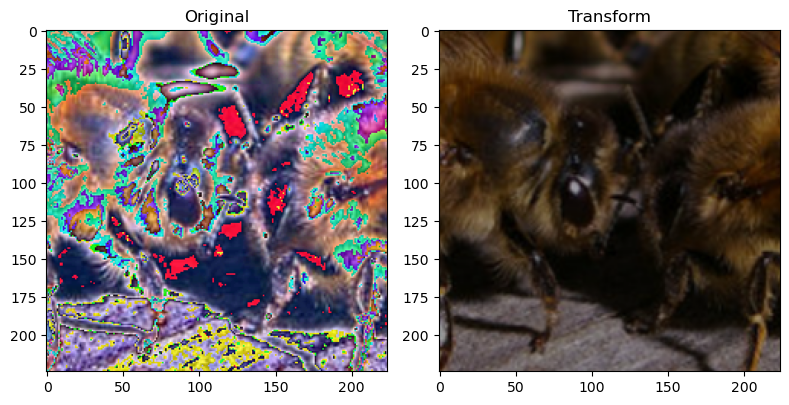

In [6]:
images, labels = next(iter(dataloaders["train"]))
mean = torch.tensor([0.485, 0.456, 0.406]).reshape(1, 3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).reshape(1, 3, 1, 1).to(device)
transformed_images = images.to(device) * std + mean

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(transforms.ToPILImage()(images[0]))
axes[0].set_title("Original")

axes[1].imshow(transforms.ToPILImage()(transformed_images[0]))
axes[1].set_title("Transform")

plt.tight_layout()
plt.show()

In [ ]:
def train_epoch(model, train_loader, loss_function, optimizer, scheduler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    train_accuracy = 100 * correct / total
    print(f"train loss: {running_loss / total:.3f} | train accuracy: {train_accuracy:.1f}")
    running_loss = 0.0
    scheduler.step()


def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
    
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    return 100 * correct / total

In [20]:
def visualization(model, device, num_images=2):
    model.eval()
    total_image = 0
    fig, axes = plt.subplots(1, num_images, figsize=(8,4))

    with torch.no_grad():
        for inputs, targets in dataloaders["val"]:
            inputs, targets = inputs.to(device), targets.to(device)

            batch_size = inputs.size(0)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            for i in range(batch_size):
                transformed_images = (inputs[i] * std + mean).squeeze(0)

                axes[total_image].imshow(transforms.ToPILImage()(transformed_images))
                axes[total_image].set_title(f"{class_names[predicted[i]]}")
                plt.tight_layout()

                total_image += 1
                if total_image == num_images:
                    return

In [9]:
# Finetuning

num_features = model.fc.in_features
num_classes = len(class_names)
new_fc_layer = nn.Linear(num_features, num_classes)
model.fc = new_fc_layer

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
model = model.to(device)

In [10]:
num_epochs = 25

for epoch in range(num_epochs):
    print(f"Epoch {epoch}")
    train_epoch(model, dataloaders["train"], loss_function, optimizer, scheduler, device)
    accuracy = evaluate(model, dataloaders["val"], device)
    print(f"val accuracy: {accuracy:.1f}")

Epoch 0
train loss: 0.178 | train accuracy: 66.8
val accuracy: 90.8
Epoch 1
train loss: 0.160 | train accuracy: 73.0
val accuracy: 83.7
Epoch 2
train loss: 0.141 | train accuracy: 79.9
val accuracy: 88.2
Epoch 3
train loss: 0.123 | train accuracy: 84.8
val accuracy: 77.8
Epoch 4
train loss: 0.135 | train accuracy: 79.5
val accuracy: 85.6
Epoch 5
train loss: 0.134 | train accuracy: 79.5
val accuracy: 88.2
Epoch 6
train loss: 0.122 | train accuracy: 85.2
val accuracy: 81.7
Epoch 7
train loss: 0.125 | train accuracy: 79.1
val accuracy: 79.1
Epoch 8
train loss: 0.139 | train accuracy: 78.3
val accuracy: 83.7
Epoch 9
train loss: 0.097 | train accuracy: 85.2
val accuracy: 88.9
Epoch 10
train loss: 0.068 | train accuracy: 87.3
val accuracy: 92.2
Epoch 11
train loss: 0.091 | train accuracy: 84.8
val accuracy: 89.5
Epoch 12
train loss: 0.090 | train accuracy: 86.1
val accuracy: 91.5
Epoch 13
train loss: 0.069 | train accuracy: 89.3
val accuracy: 90.8
Epoch 14
train loss: 0.106 | train accuracy:

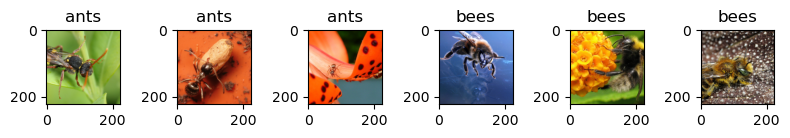

In [18]:
visualization(model, device, 6)

In [61]:
# ConvNet as fixed features extractor

model_fixed = tv_model.resnet18(weights="IMAGENET1K_V1")
for param in model_fixed.parameters():
    param.requires_grad = False

num_in_features = model_fixed.fc.in_features 
fc_layer = nn.Linear(num_in_features, num_classes)
model_fixed.fc = fc_layer
model_fixed = model_fixed.to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_fixed.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [62]:
num_epochs = 25

for epoch in range(num_epochs):
    print(f"Epoch {epoch}")
    train_epoch(model_fixed, dataloaders["train"], loss_function, optimizer, scheduler, device)
    accuracy = evaluate(model_fixed, dataloaders["val"], device)
    print(f"val accuracy: {accuracy:.1f}")

Epoch 0
train loss: 0.155 | train accuracy: 66.8
val accuracy: 92.8
Epoch 1
train loss: 0.172 | train accuracy: 73.8
val accuracy: 85.6
Epoch 2
train loss: 0.127 | train accuracy: 76.6
val accuracy: 88.9
Epoch 3
train loss: 0.132 | train accuracy: 76.2
val accuracy: 73.2
Epoch 4
train loss: 0.154 | train accuracy: 78.3
val accuracy: 94.8
Epoch 5
train loss: 0.145 | train accuracy: 76.6
val accuracy: 92.2
Epoch 6
train loss: 0.120 | train accuracy: 80.7
val accuracy: 86.3
Epoch 7
train loss: 0.126 | train accuracy: 78.3
val accuracy: 90.8
Epoch 8
train loss: 0.125 | train accuracy: 79.5
val accuracy: 94.1
Epoch 9
train loss: 0.106 | train accuracy: 83.2
val accuracy: 90.2
Epoch 10
train loss: 0.082 | train accuracy: 85.7
val accuracy: 94.1
Epoch 11
train loss: 0.091 | train accuracy: 81.1
val accuracy: 94.8
Epoch 12
train loss: 0.106 | train accuracy: 80.3
val accuracy: 90.8
Epoch 13
train loss: 0.101 | train accuracy: 81.1
val accuracy: 92.8
Epoch 14
train loss: 0.101 | train accuracy:

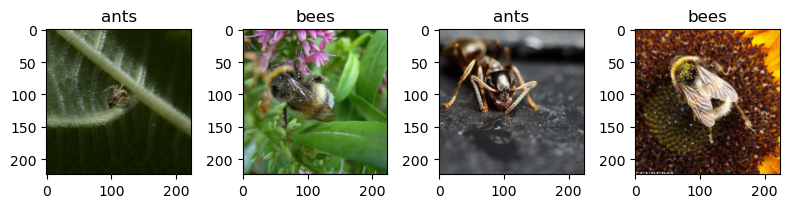

In [63]:
visualization(model_fixed, device, 4)